In [121]:
import importlib
import src.ingestion
import src.preproc
import src.eda
import src.garch
import src.dy_connectedness
import src.diversification
import src.lstm
importlib.reload(src.ingestion)
importlib.reload(src.preproc)
importlib.reload(src.eda)
importlib.reload(src.garch)
importlib.reload(src.dy_connectedness)
importlib.reload(src.diversification)
importlib.reload(src.lstm)
from src.ingestion import *
from src.preproc import *
from src.eda import *
from src.garch import *
from src.dy_connectedness import *
from src.diversification import *
from src.lstm import *
unified = pd.read_csv(filepath_or_buffer=r"insights\unified.csv")

### Data Loading and Preprocessing

In [ ]:
download_assets()   

=== Asset Price Data Collection ===


[*********************100%***********************]  1 of 1 completed


Saved → dataset\BTC-USD.csv


[*********************100%***********************]  1 of 1 completed


Saved → dataset\ETH-USD.csv


...

Saved → dataset\HKD=X.csv


[*********************100%***********************]  1 of 1 completed


Saved → dataset\BRL=X.csv


[*********************100%***********************]  1 of 1 completed

Saved → dataset\AUD=X.csv
=== Data Collection Complete ===


In [16]:
nan_summary = check_nan_across_files()
nan_summary.head()

=== NaN CHECK ACROSS ALL FILES ===

File: AUD=X.csv
Shape: (1564, 7)
Total NaNs: 0 (0.0000%)
No NaNs found.
--------------------------------------------------
File: BRL=X.csv
Shape: (1564, 7)
Total NaNs: 0 (0.0000%)
No NaNs found.
--------------------------------------------------
File: BTC-USD.csv
Shape: (2191, 7)
Total NaNs: 0 (0.0000%)
No NaNs found.
--------------------------------------------------
File: CAD=X.csv
Shape: (1564, 7)
Total NaNs: 0 (0.0000%)
No NaNs found.
--------------------------------------------------
File: ETH-USD.csv
Shape: (2191, 7)
Total NaNs: 0 (0.0000%)
No NaNs found.
--------------------------------------------------
File: GC=F.csv
Shape: (1509, 7)
Total NaNs: 0 (0.0000%)
No NaNs found.
--------------------------------------------------
File: HKD=X.csv
Shape: (1564, 7)
Total NaNs: 0 (0.0000%)
No NaNs found.
--------------------------------------------------
File: USDINR=X.csv
Shape: (1564, 7)
Total NaNs: 0 (0.0000%)
No NaNs found.
-------------------------

,file,rows,cols,total_nans,nan_pct
0,AUD=X.csv,1564,7,0,0.0
1,BRL=X.csv,1564,7,0,0.0
2,BTC-USD.csv,2191,7,0,0.0
3,CAD=X.csv,1564,7,0,0.0
4,ETH-USD.csv,2191,7,0,0.0


In [17]:
calendar_summary = check_calendar_alignment()
calendar_summary.head()

=== CALENDAR ALIGNMENT CHECK ===

Global date range: 2019-01-01 → 2024-12-30
Total unique dates (union): 2191

Common dates across ALL assets: 1291
Overlap ratio: 0.5892

AUD=X:
  available: 1564
  missing: 627 (28.62%)
  sample missing: [datetime.date(2019, 1, 5), datetime.date(2019, 1, 6), datetime.date(2019, 1, 12), datetime.date(2019, 1, 13), datetime.date(2019, 1, 19)]
----------------------------------------
BRL=X:
  available: 1564
  missing: 627 (28.62%)
  sample missing: [datetime.date(2019, 1, 5), datetime.date(2019, 1, 6), datetime.date(2019, 1, 12), datetime.date(2019, 1, 13), datetime.date(2019, 1, 19)]
----------------------------------------
BTC-USD:
  available: 2191
  missing: 0 (0.00%)
----------------------------------------
CAD=X:
  available: 1564
  missing: 627 (28.62%)
  sample missing: [datetime.date(2019, 1, 5), datetime.date(2019, 1, 6), datetime.date(2019, 1, 12), datetime.date(2019, 1, 13), datetime.date(2019, 1, 19)]
----------------------------------------

,ticker,available_dates,missing_dates,missing_pct
12,^HSI,1475,716,32.679142
13,^NSEI,1477,714,32.587859
9,^BVSP,1492,699,31.903241
11,^GSPTSE,1505,686,31.309904
5,GC=F,1509,682,31.127339


In [18]:
keep_common_dates()

=== KEEPING ONLY COMMON DATES ACROSS ALL ASSETS ===

Common dates retained: 1291
AUD=X: 1564 → 1291 rows
BRL=X: 1564 → 1291 rows
BTC-USD: 2191 → 1291 rows
CAD=X: 1564 → 1291 rows
ETH-USD: 2191 → 1291 rows
GC=F: 1509 → 1291 rows
HKD=X: 1564 → 1291 rows
USDINR=X: 1564 → 1291 rows
^AXJO: 1517 → 1291 rows
^BVSP: 1492 → 1291 rows
^GSPC: 1509 → 1291 rows
^GSPTSE: 1505 → 1291 rows
^HSI: 1475 → 1291 rows
^NSEI: 1477 → 1291 rows

=== ALL FILES NOW PERFECTLY ALIGNED ===


In [19]:
convert_all_to_inr()

=== CONVERTING ALL ASSETS TO INR ===

Processing BTC-USD...
✔ Converted BTC-USD to INR
Processing ETH-USD...
✔ Converted ETH-USD to INR
Processing GC=F...
✔ Converted GC=F to INR
Processing ^AXJO...
✔ Converted ^AXJO to INR
Processing ^BVSP...
✔ Converted ^BVSP to INR
Processing ^GSPC...
✔ Converted ^GSPC to INR
Processing ^GSPTSE...
✔ Converted ^GSPTSE to INR
Processing ^HSI...
✔ Converted ^HSI to INR
Processing ^NSEI...
✔ Converted ^NSEI to INR

=== ALL FILES CONVERTED TO INR ===


### EDA

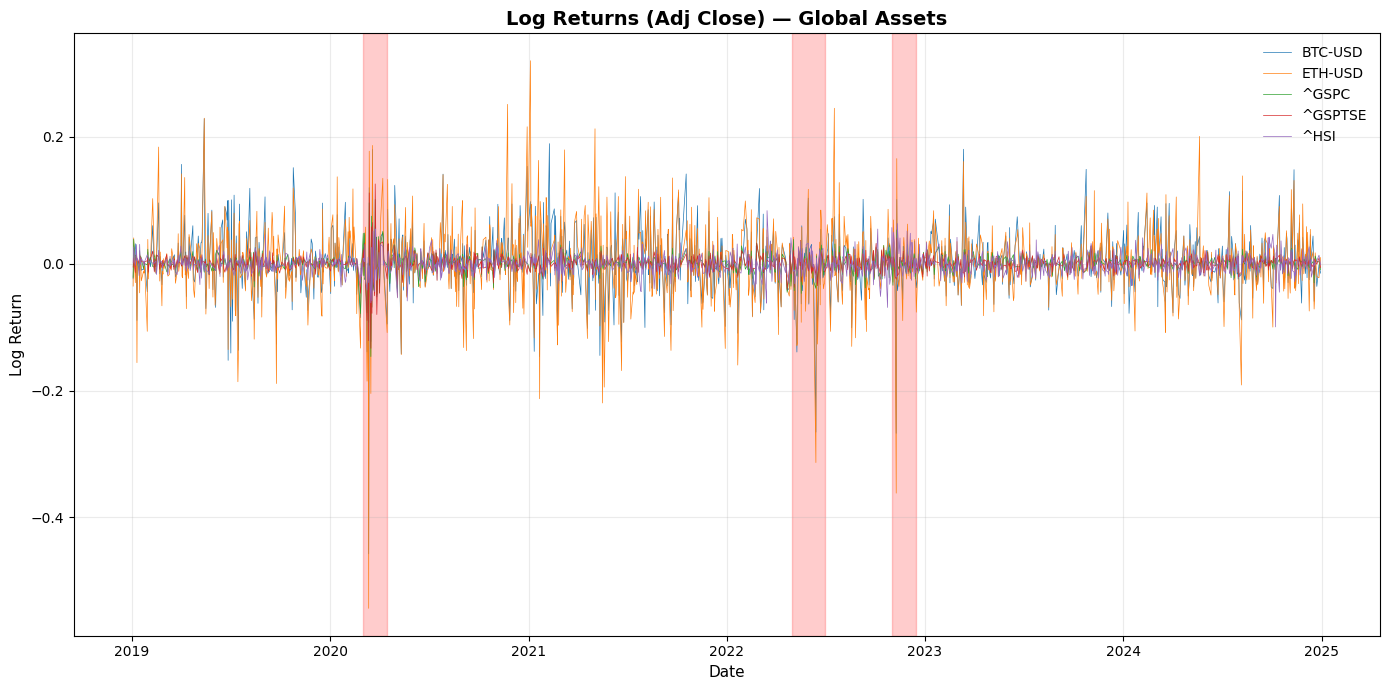

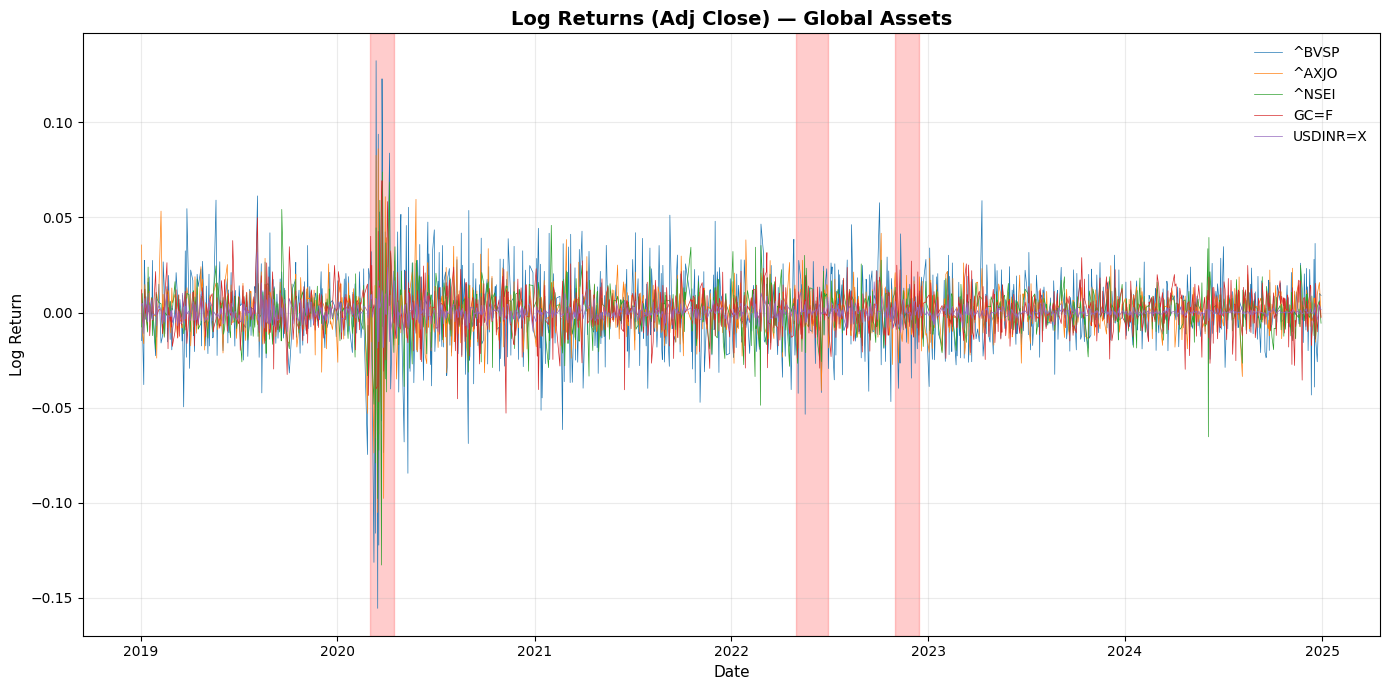

In [20]:
plot_global_log_returns(batch_size=5)

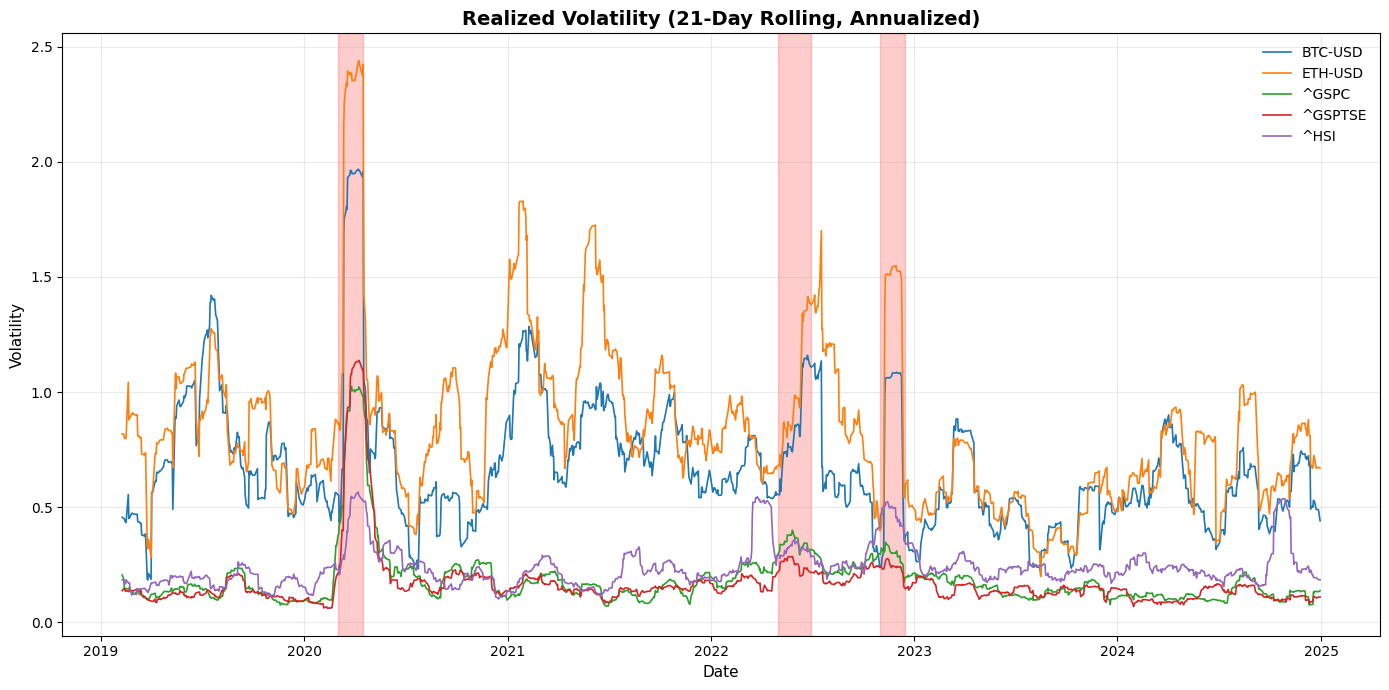

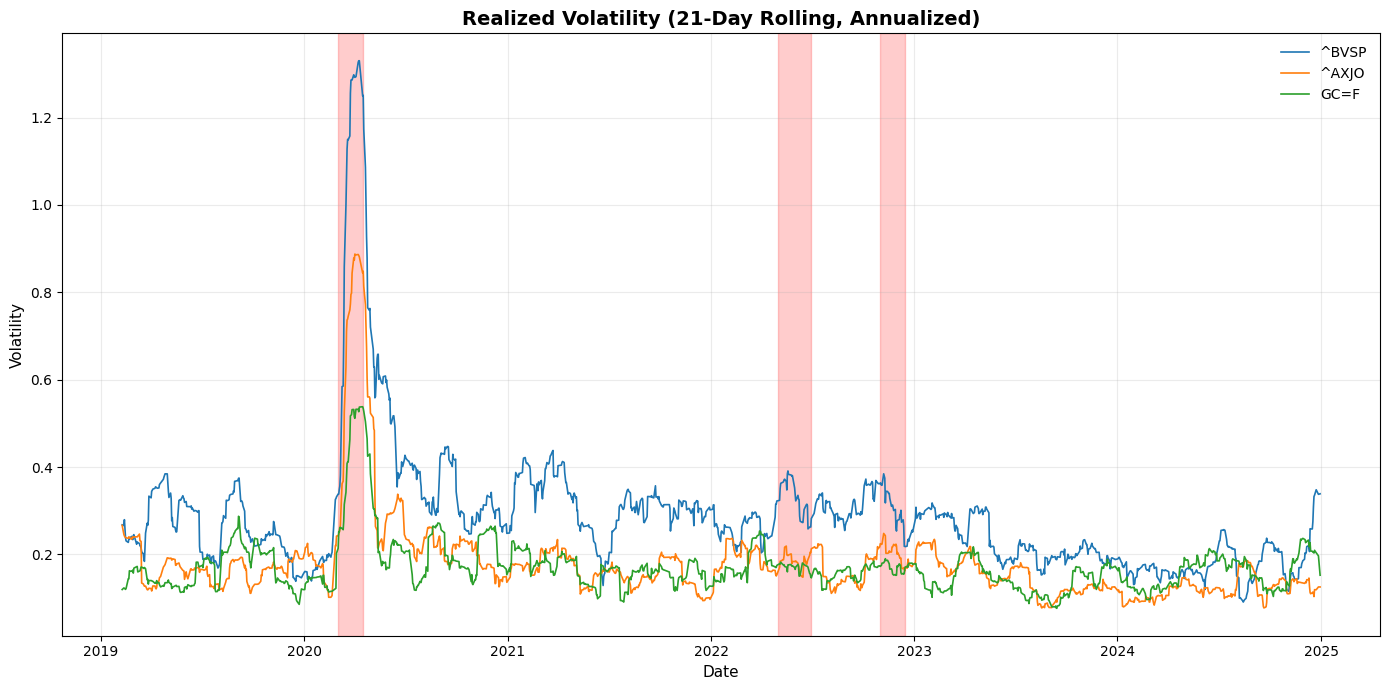

In [21]:
plot_realized_volatility(batch_size=5)

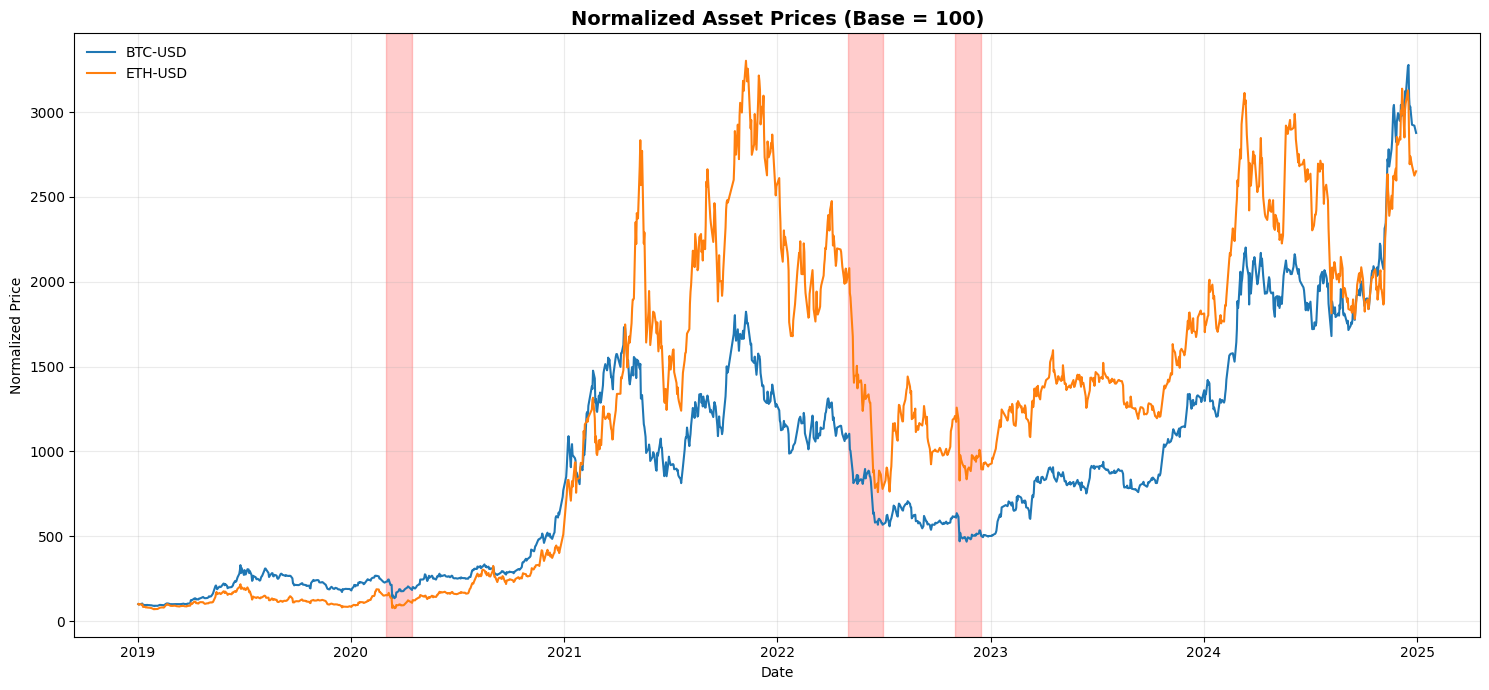

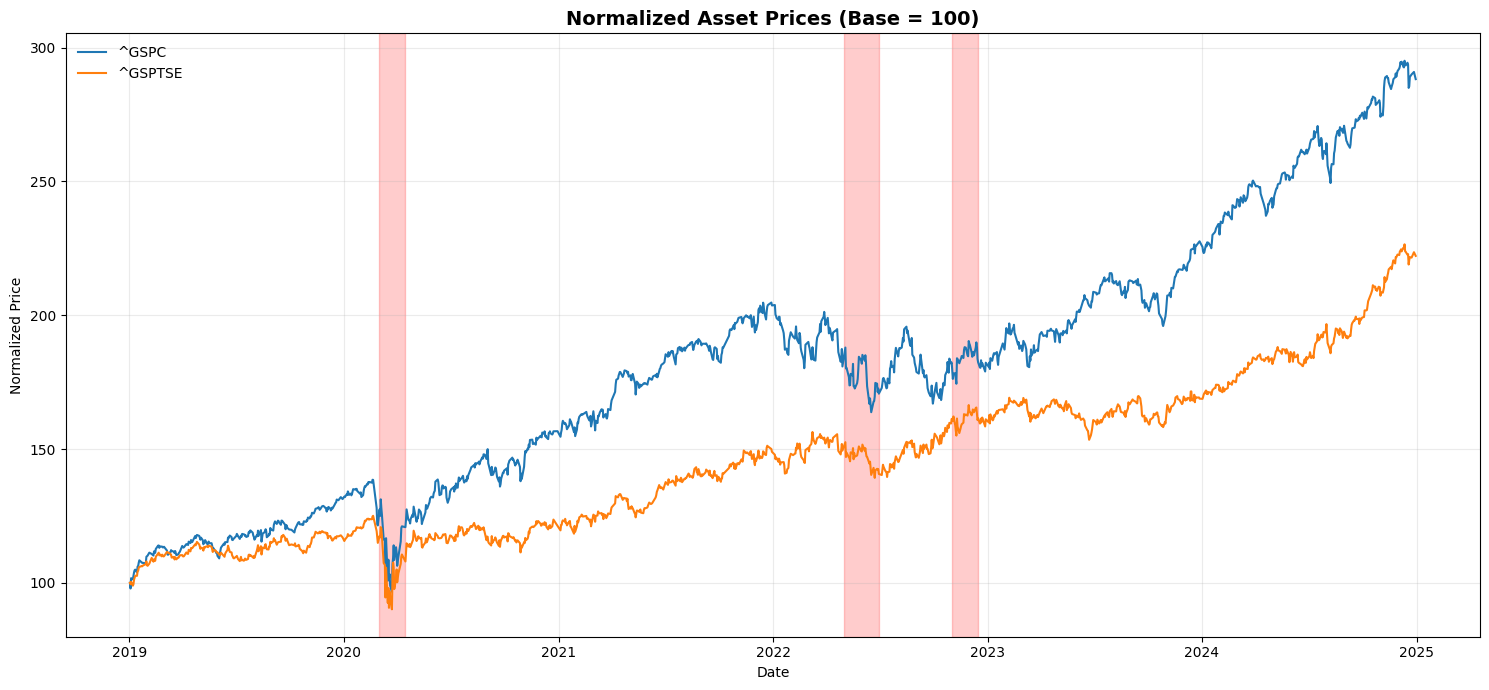

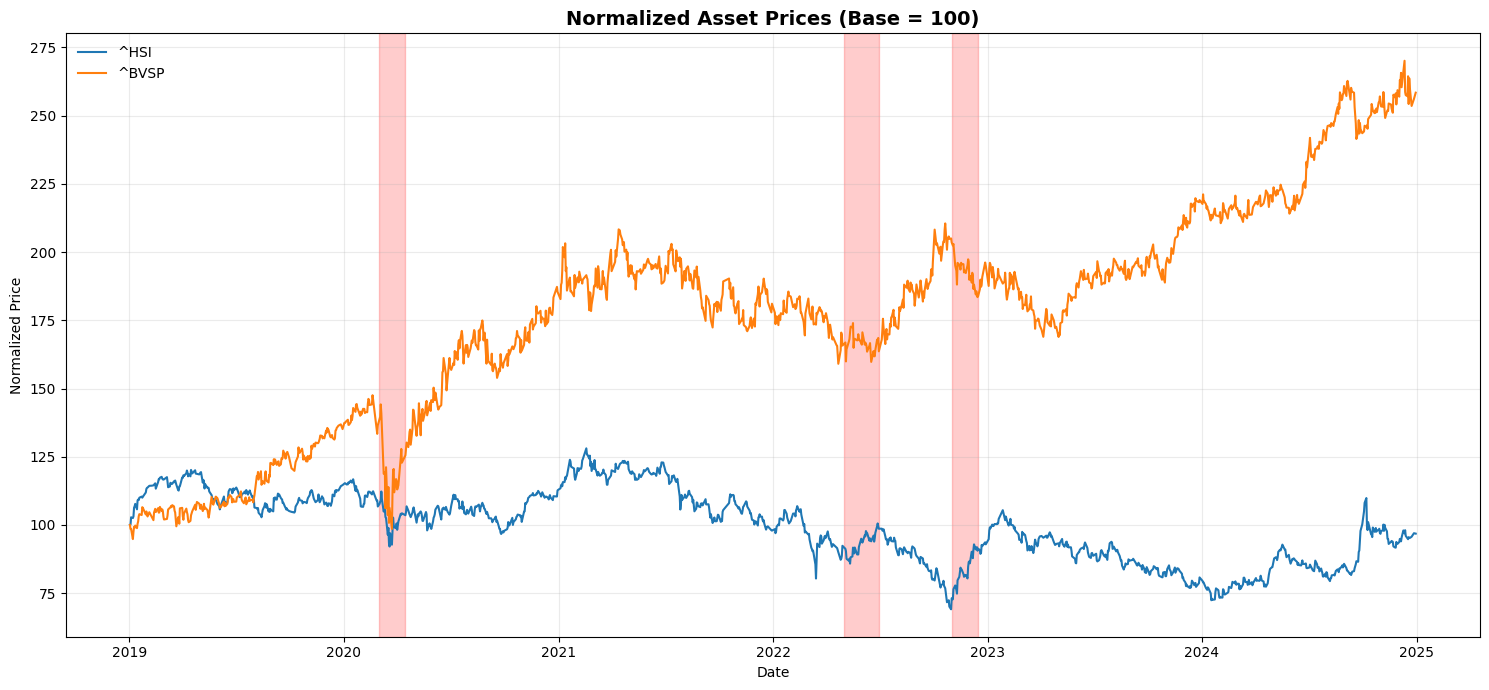

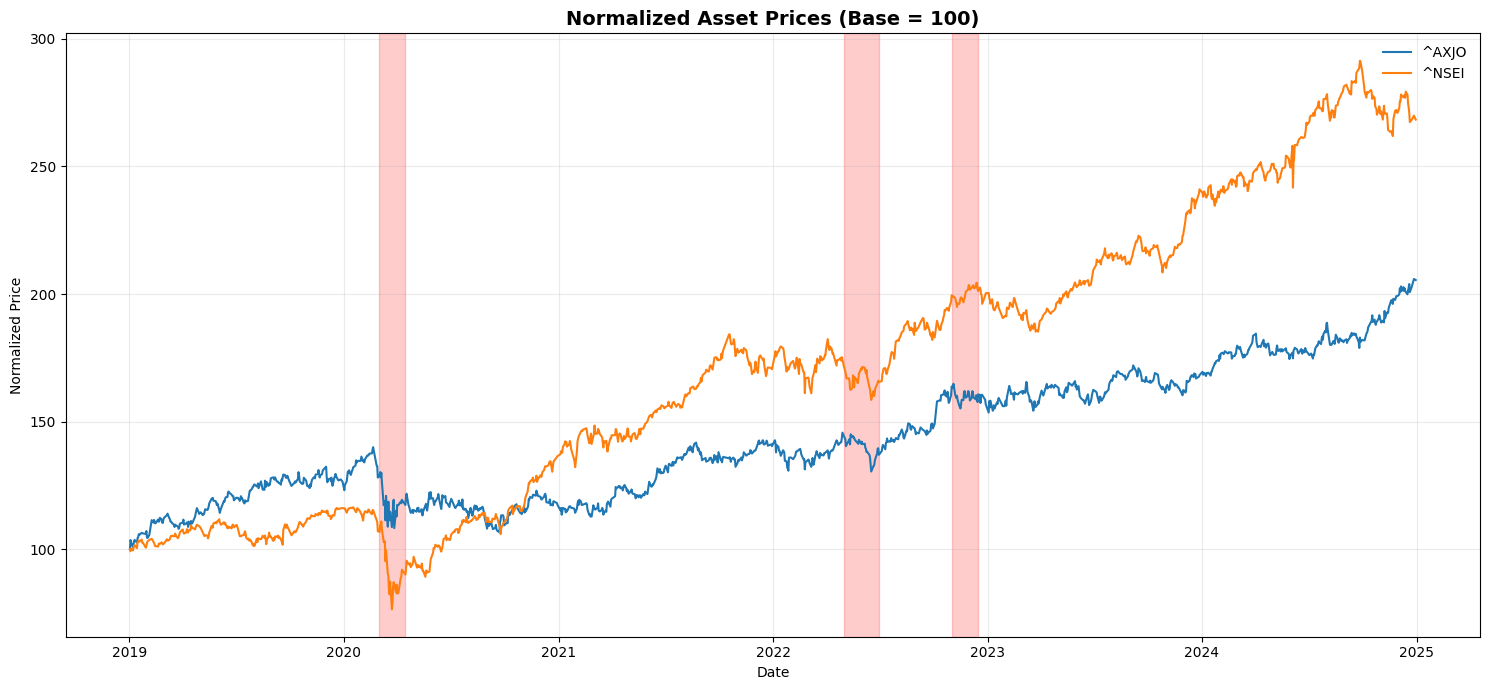

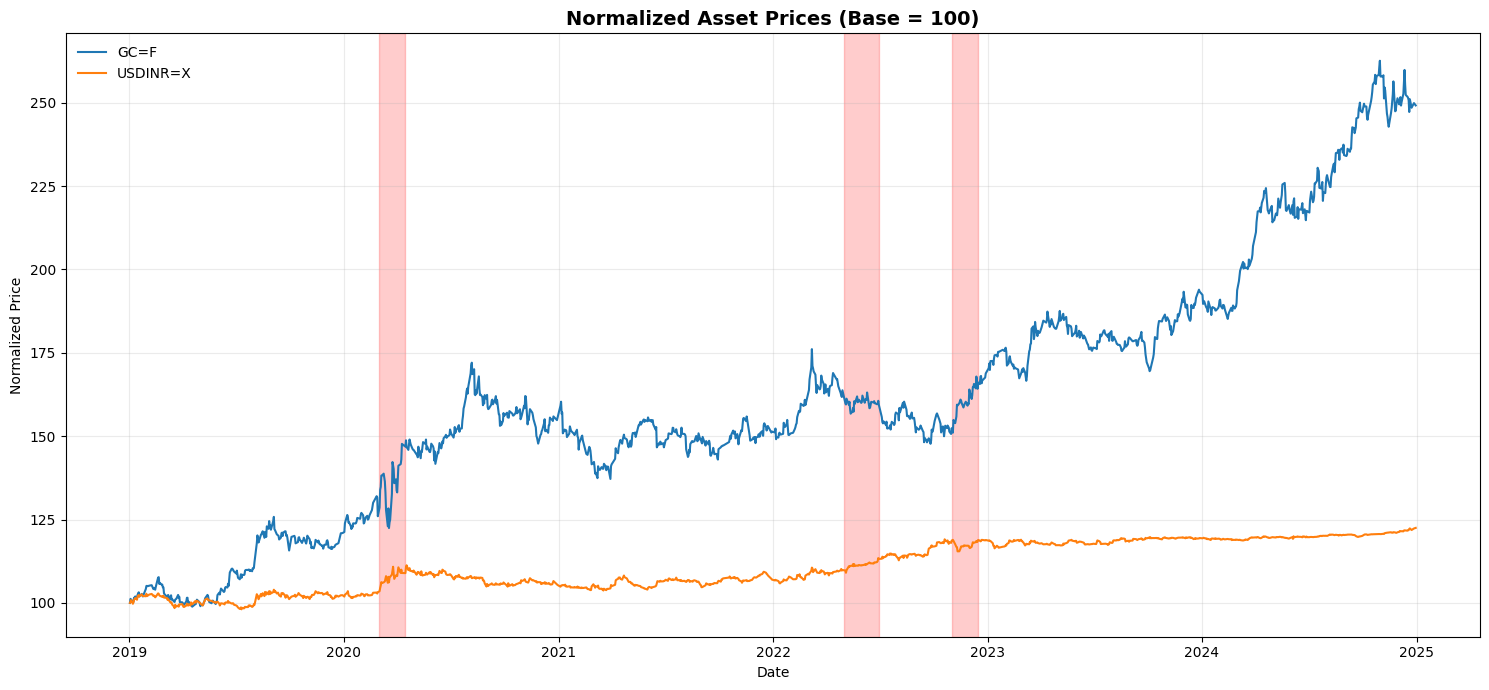

In [22]:
plot_normalized_prices(batch_size=2)

In [23]:
unified = build_unified_matrix()

Saved unified matrix → insights\unified.csv

=== UNIFIED MATRIX INFO ===
(1270, 21)
        date  ret_BTC-USD  vol_BTC-USD  ret_ETH-USD  vol_ETH-USD  ret_^GSPC  \
0 2019-02-08     0.060084     0.455306     0.102687     0.817933  -0.004461   
1 2019-02-11    -0.011042     0.449766     0.010857     0.816447  -0.005317   
2 2019-02-12     0.002520     0.447978     0.011571     0.800146   0.013932   
3 2019-02-14    -0.015218     0.433065    -0.014827     0.797218  -0.004772   
4 2019-02-15     0.003129     0.432480     0.007876     0.799406   0.012863   

   vol_^GSPC  ret_^GSPTSE  vol_^GSPTSE  ret_^HSI  ...  ret_^BVSP  vol_^BVSP  \
0   0.204409     0.019826     0.136461  0.000429  ...  -0.016058   0.267694   
1   0.184873    -0.012929     0.145358  0.000979  ...  -0.012146   0.265827   
2   0.144868     0.007771     0.145073  0.002164  ...   0.026650   0.279514   
3   0.145387    -0.004776     0.134063  0.004344  ...   0.013355   0.238740   
4   0.144710     0.013916     0.138136 -0.0170

### DCC GARCH

In [24]:
resid, vol, summary = run_univariate_garch()

=== RUNNING UNIVARIATE GARCH ===

Processing BTC-USD...
Processing ETH-USD...
Processing ^GSPC...
Processing ^GSPTSE...
Processing ^HSI...
Processing ^BVSP...
Processing ^AXJO...
Processing ^NSEI...
Processing GC=F...
Processing USDINR=X...

=== GARCH SUMMARY ===
      asset      arch_pval     omega        nu     alpha      beta  alpha_beta
0   BTC-USD   4.934101e-06  0.559920  2.894859  0.082946  0.916729    0.999675
1   ETH-USD   2.715472e-10  0.723527  3.150299  0.071763  0.920984    0.992748
2     ^GSPC   1.015926e-90  0.047244  6.964472  0.139756  0.832318    0.972075
3   ^GSPTSE  3.941175e-102  0.089873  9.323116  0.150214  0.766874    0.917088
4      ^HSI   5.884905e-23  0.118962  7.288337  0.082327  0.870743    0.953070
5     ^BVSP   1.582704e-96  0.068306  8.610441  0.081226  0.900817    0.982043
6     ^AXJO   1.519206e-92  0.130839  6.423458  0.123066  0.774442    0.897508
7     ^NSEI   4.218730e-73  0.068583  5.361197  0.116849  0.827641    0.944490
8      GC=F   6.318982e-2

In [25]:
dcc_corrs, dcc_summary = run_dcc_garch()

=== RUNNING DCC-GARCH ===
Observations: 1269
Assets: 10

=== DCC SUMMARY ===
               pair  full_sample_corr  covid_crash  luna_collapse  \
0  BTC-USD__ETH-USD          0.826657     0.897655       0.899753   
1    BTC-USD__^GSPC          0.287249     0.392373       0.510235   
2  BTC-USD__^GSPTSE          0.280342     0.509734       0.451982   
3     BTC-USD__^HSI          0.082333     0.263635       0.180125   
4    BTC-USD__^BVSP          0.184499     0.423365       0.284922   

   ftx_collapse  
0      0.920191  
1      0.406064  
2      0.440825  
3      0.125671  
4      0.192214  

Saved → insights\dcc_correlations.csv
Saved → insights\dcc_summary.csv


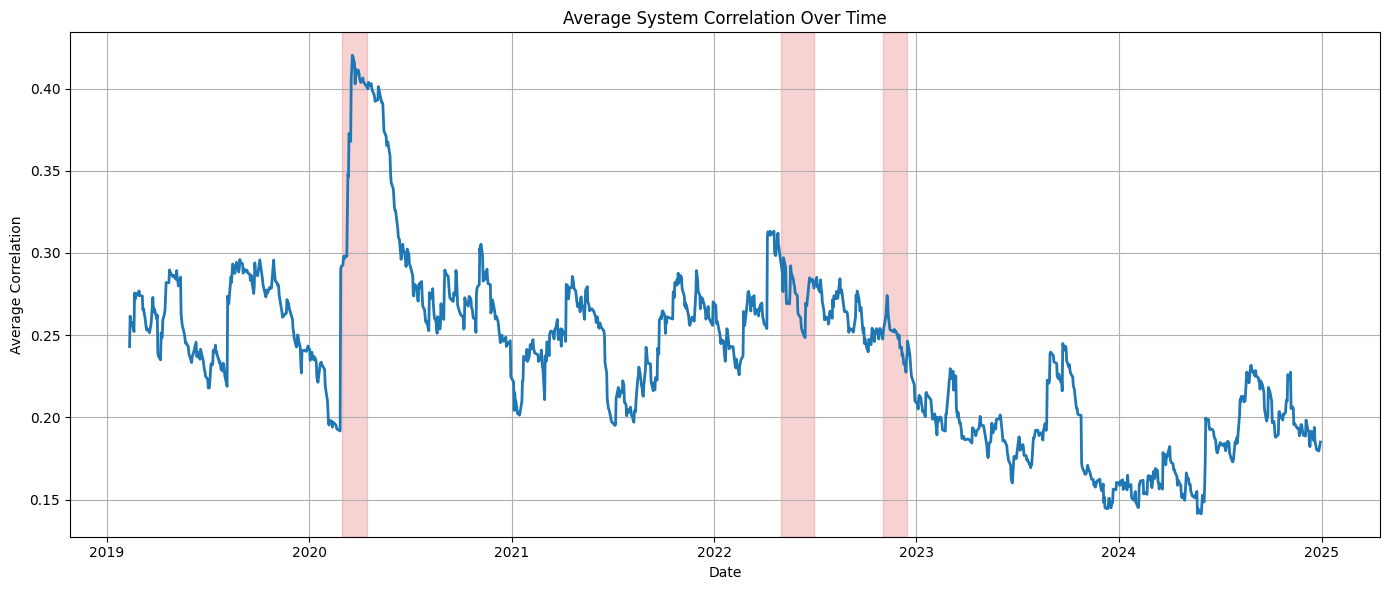

In [26]:
plot_avg_system_correlation()

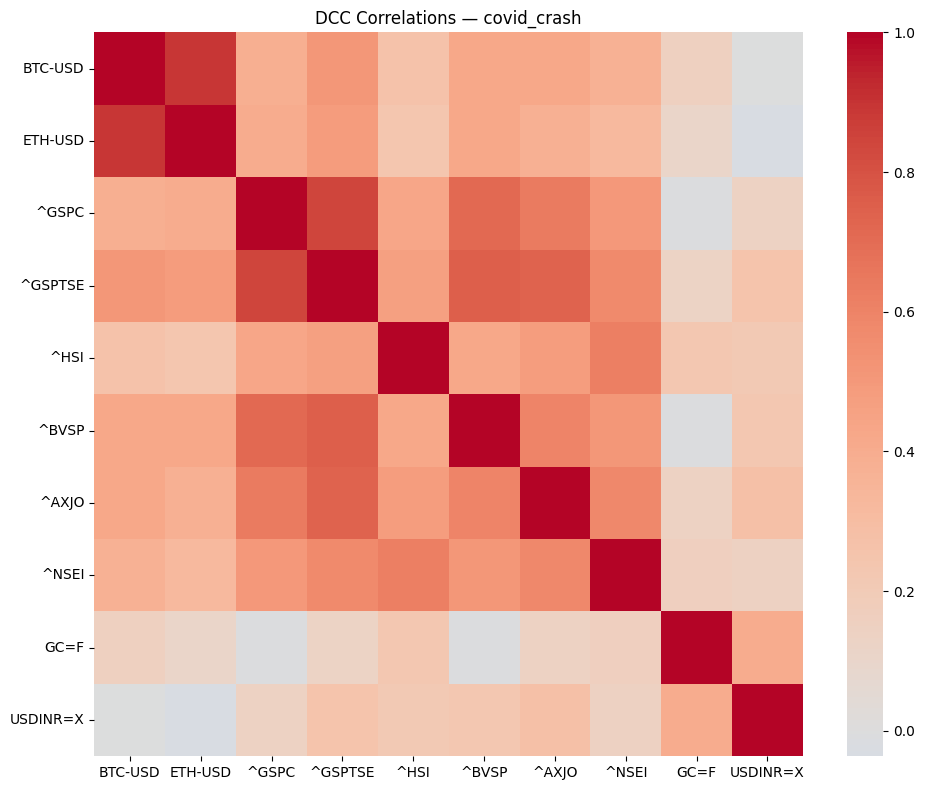

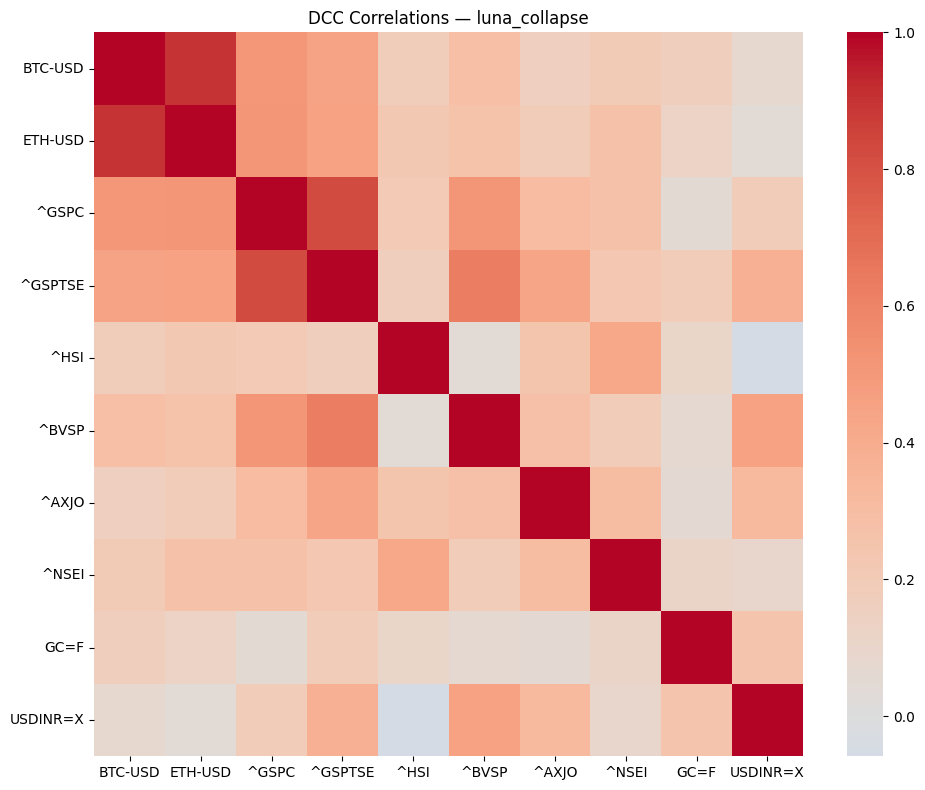

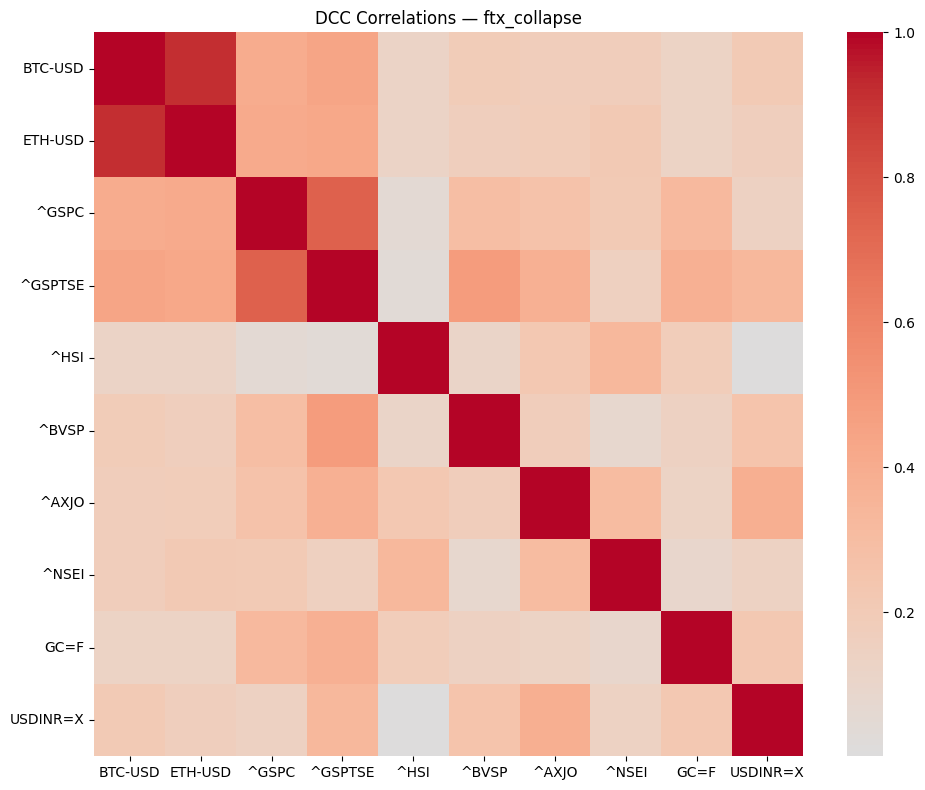

In [27]:
plot_regime_correlation_heatmaps()

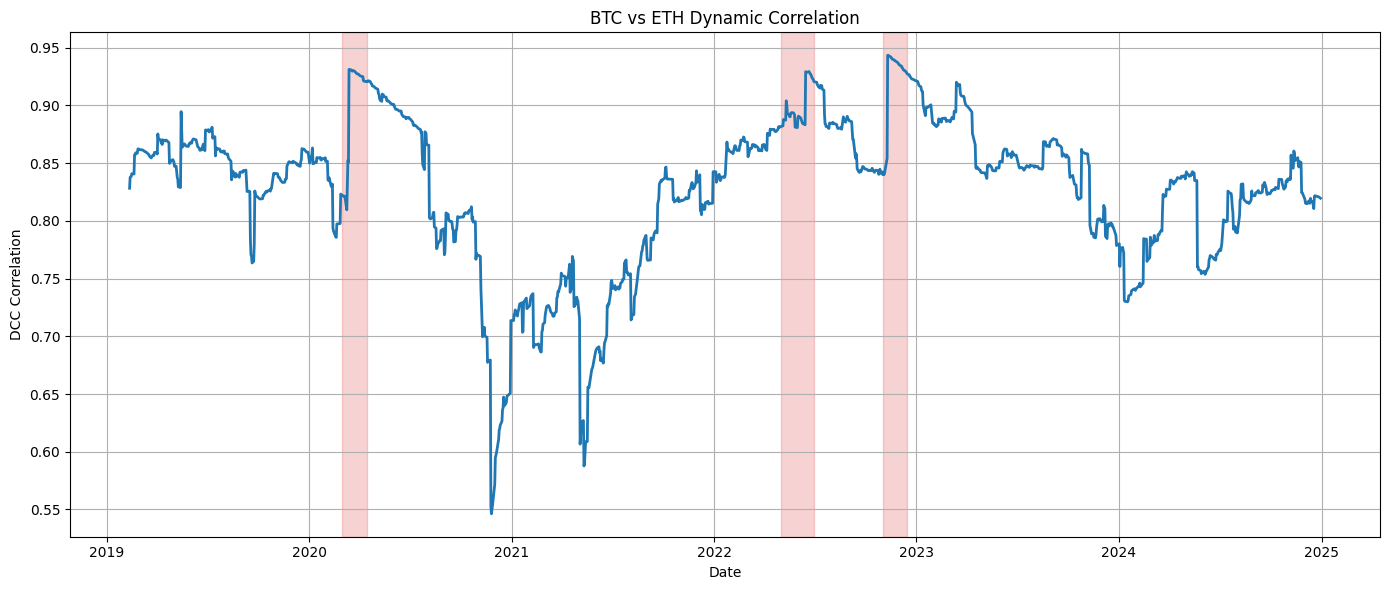

In [28]:
plot_btc_eth_dcc()

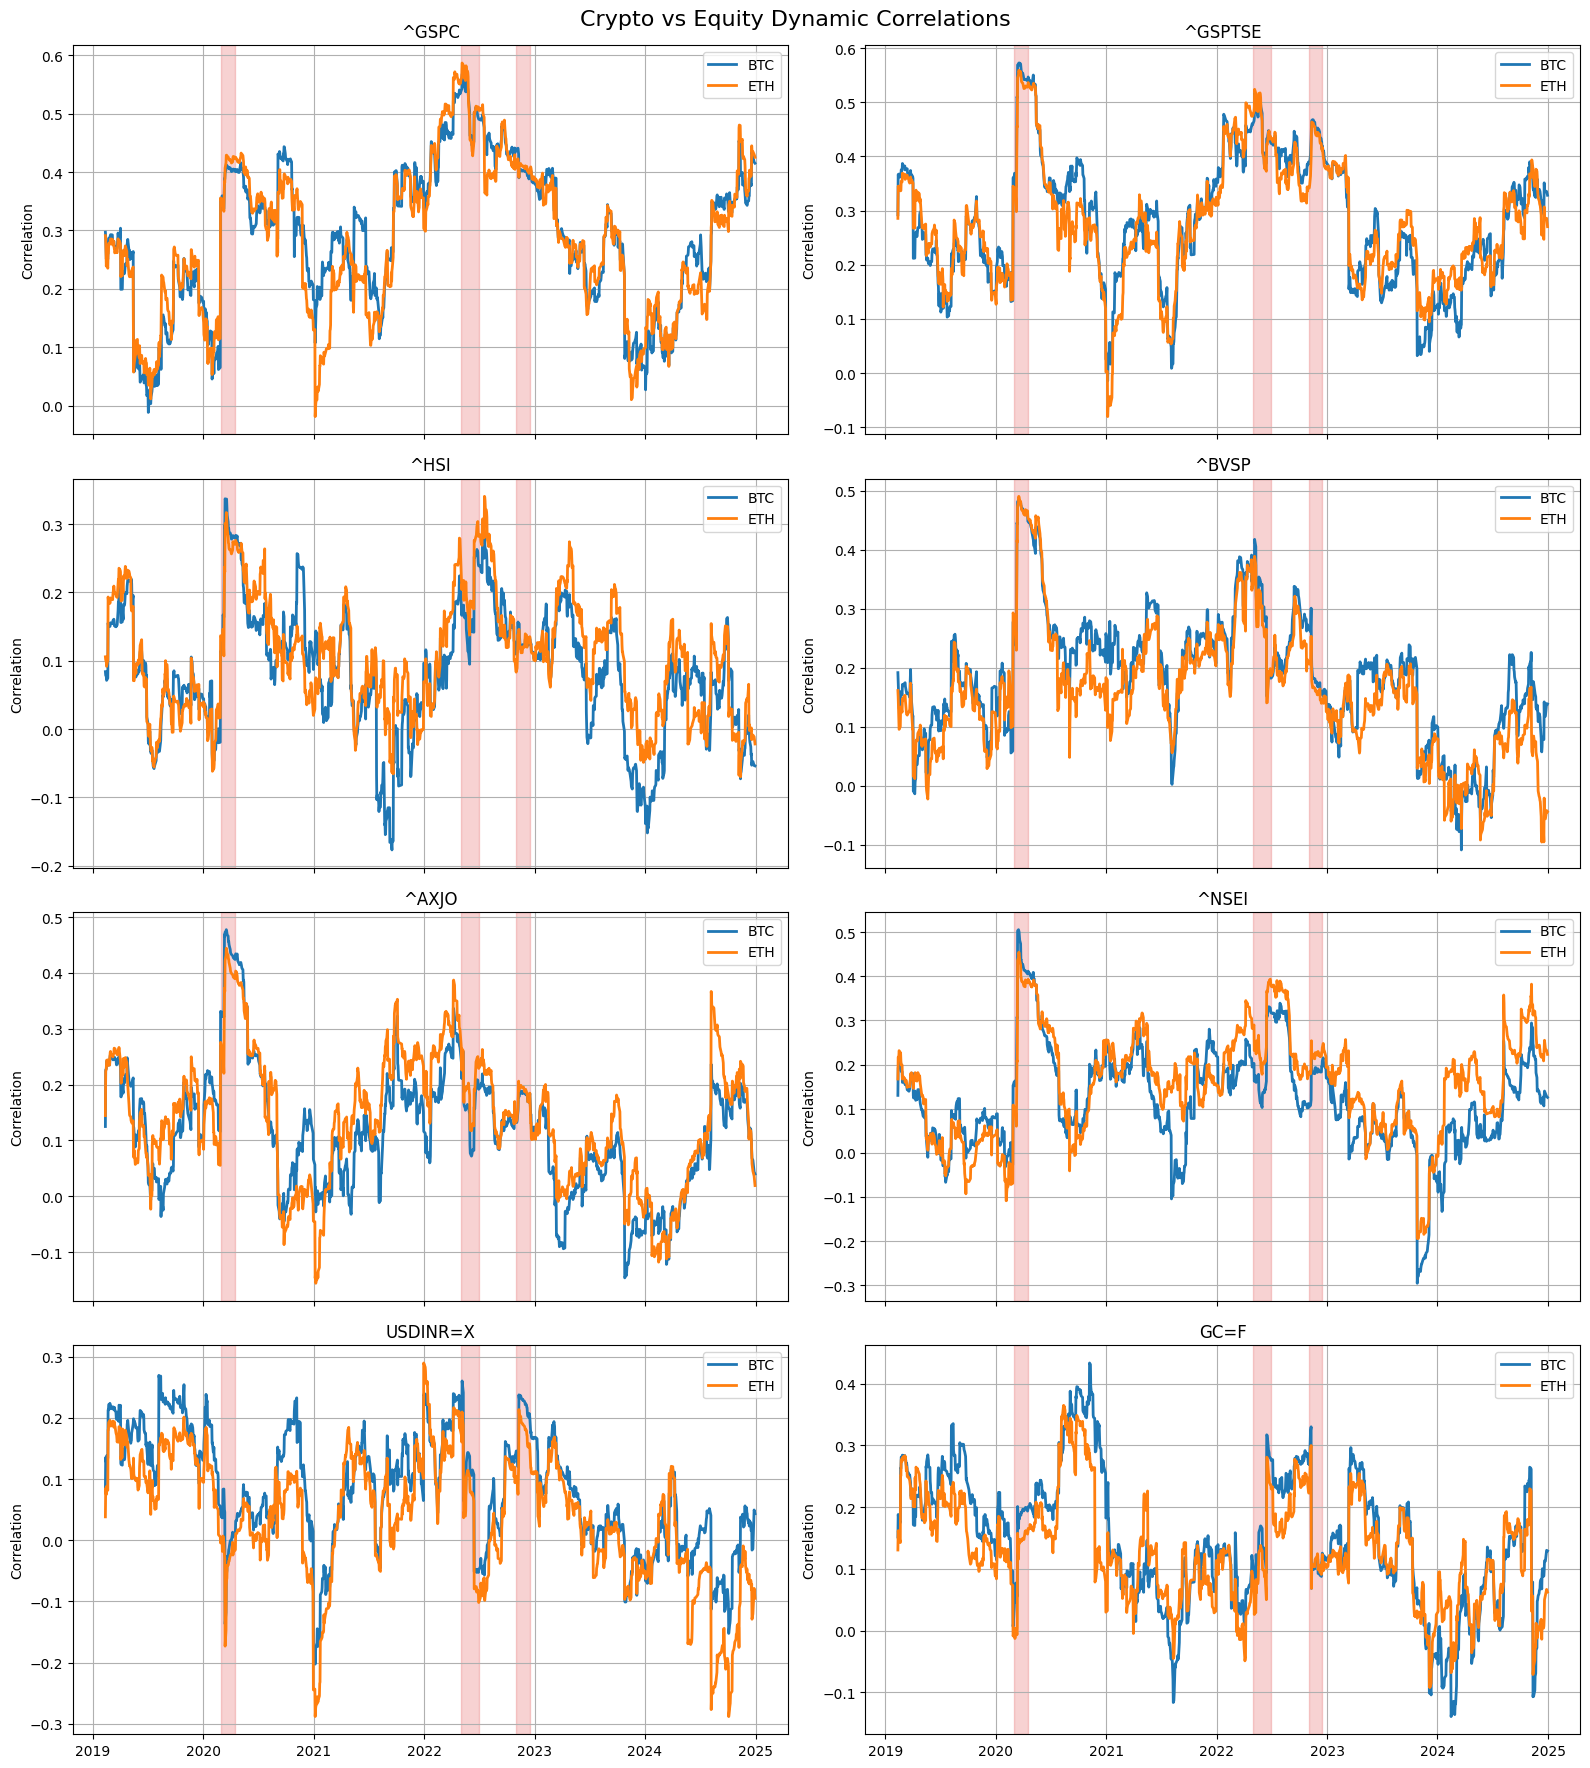

In [29]:
plot_crypto_equity_dcc()

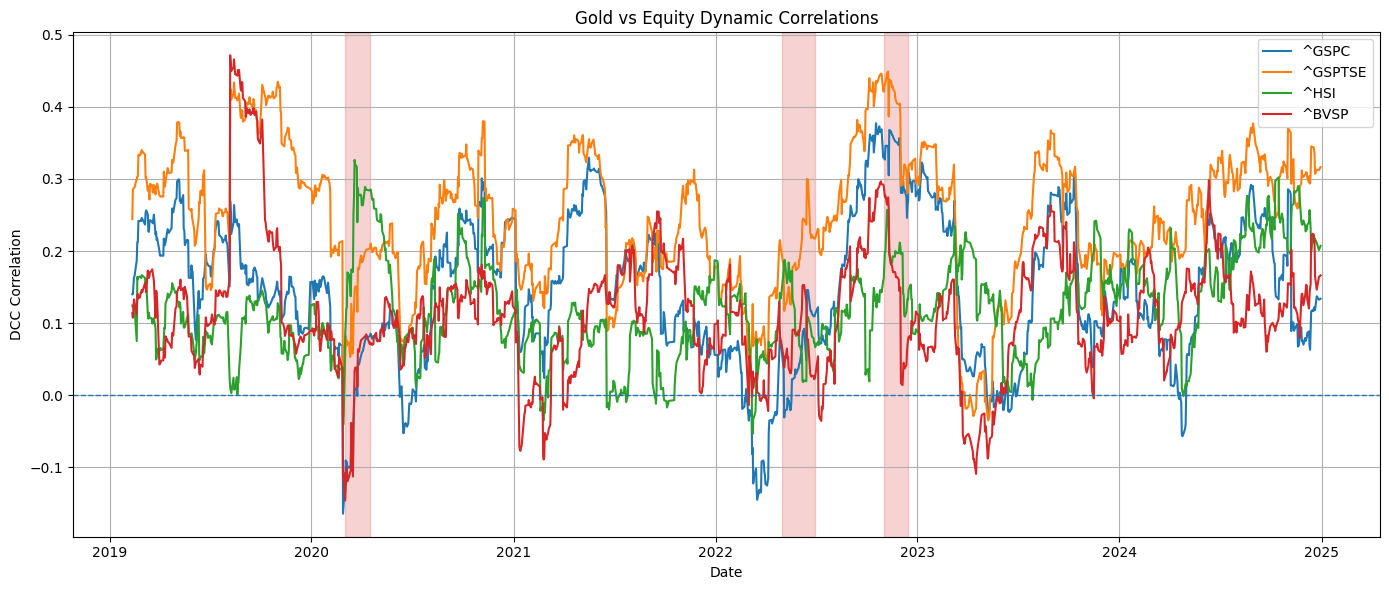

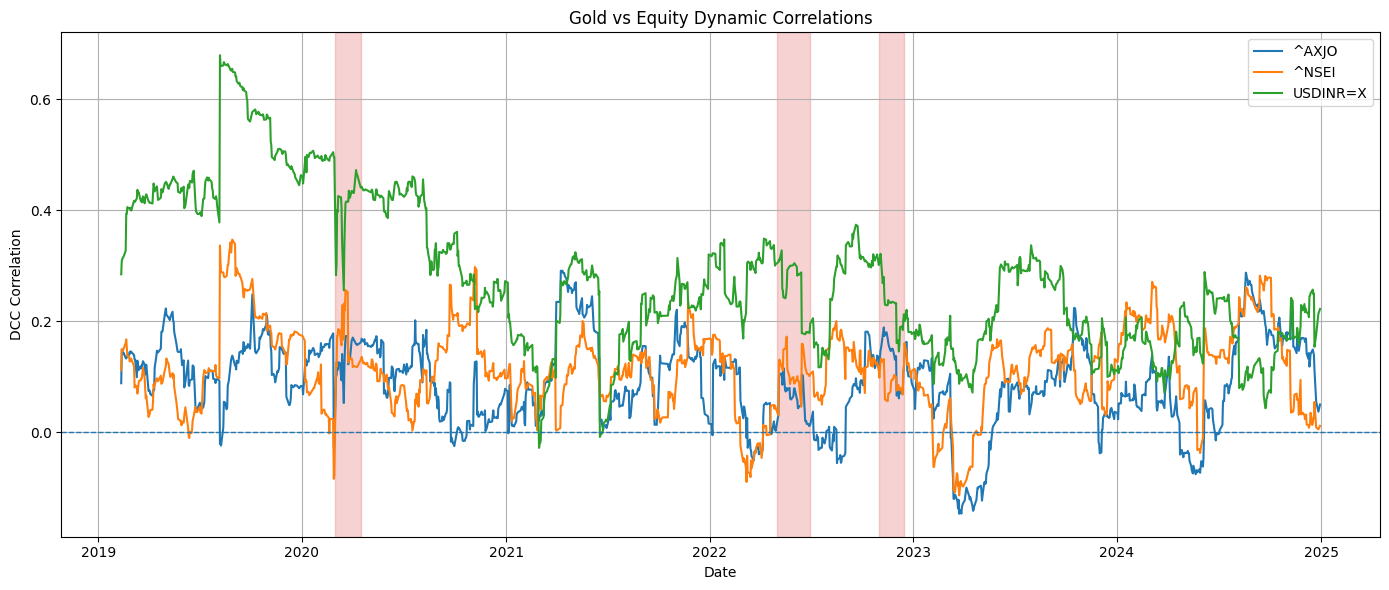

In [30]:
plot_gold_safe_haven(batch_size=4)

### Diemold Yilmaz Connectedness

In [31]:
run_full_sample_dy()


=== TOTAL CONNECTEDNESS INDEX ===
TCI: 26.96%

=== CONNECTEDNESS TABLE ===
                        TO       FROM        NET
resid_BTC-USD   100.127048   0.340483  99.786565
resid_ETH-USD     4.127794  68.709241 -64.581446
resid_^GSPC      94.191376  11.325879  82.865497
resid_^GSPTSE    32.730863  56.060852 -23.329989
resid_^HSI       10.364507  11.422829  -1.058321
resid_^BVSP       4.313642  31.507517 -27.193874
resid_^AXJO       6.438994  27.828568 -21.389574
resid_^NSEI       5.225751  22.981551 -17.755800
resid_GC=F        9.431101   8.477727   0.953374
resid_USDINR=X    2.606101  30.902532 -28.296432


c:\Users\SHREY\anaconda3\envs\fin\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


(                resid_BTC-USD  resid_ETH-USD  resid_^GSPC  resid_^GSPTSE  \
 resid_BTC-USD        0.996595   6.124008e-07     0.000649       0.000056   
 resid_ETH-USD        0.684497   3.129076e-01     0.000183       0.000455   
 resid_^GSPC          0.089814   7.161744e-03     0.886741       0.004389   
 resid_^GSPTSE        0.090882   6.256415e-03     0.443044       0.439391   
 resid_^HSI           0.009281   4.544609e-03     0.064365       0.002784   
 resid_^BVSP          0.052773   2.553359e-04     0.177856       0.072371   
 resid_^AXJO          0.018442   4.338389e-03     0.072247       0.104515   
 resid_^NSEI          0.018663   1.325737e-02     0.091641       0.013044   
 resid_GC=F           0.023509   4.257349e-04     0.009007       0.036300   
 resid_USDINR=X       0.013410   5.037735e-03     0.082922       0.093396   
 
                 resid_^HSI  resid_^BVSP  resid_^AXJO  resid_^NSEI  resid_GC=F  \
 resid_BTC-USD     0.000013     0.000551     0.000296     0.000172   

In [32]:
run_regime_dy()


=== COVID Crash ===
TCI: 76.82%

=== LUNA Collapse ===
TCI: 65.71%

=== FTX Collapse ===
TCI: 65.94%


c:\Users\SHREY\anaconda3\envs\fin\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\SHREY\anaconda3\envs\fin\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\SHREY\anaconda3\envs\fin\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


,regime,tci
0,COVID Crash,76.822547
1,LUNA Collapse,65.705954
2,FTX Collapse,65.940860


In [51]:
rolling_tci()

c:\Users\SHREY\anaconda3\envs\fin\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


,date,tci
0,2019-04-01,44.106538
1,2019-04-02,44.087598
2,2019-04-03,44.388762
3,2019-04-04,46.165866
4,2019-04-08,46.248161
...,...,...
1205,2024-11-04,42.000377
1206,2024-11-05,41.320088
1207,2024-11-06,40.552844
1208,2024-11-07,40.020668


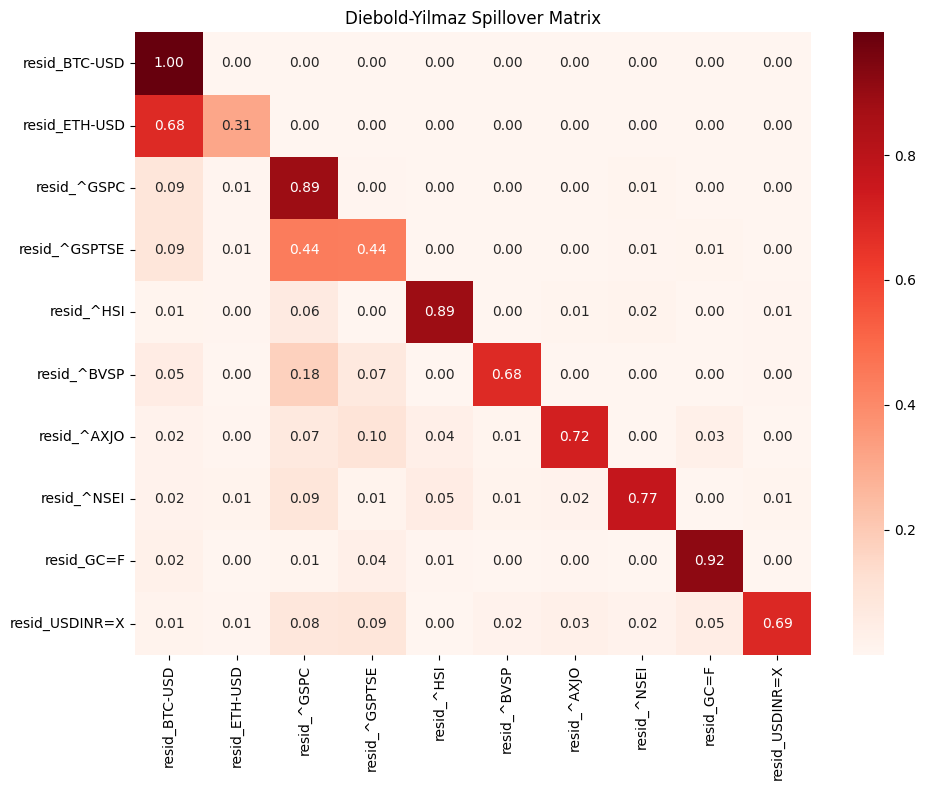

In [52]:
plot_connectedness_heatmap()

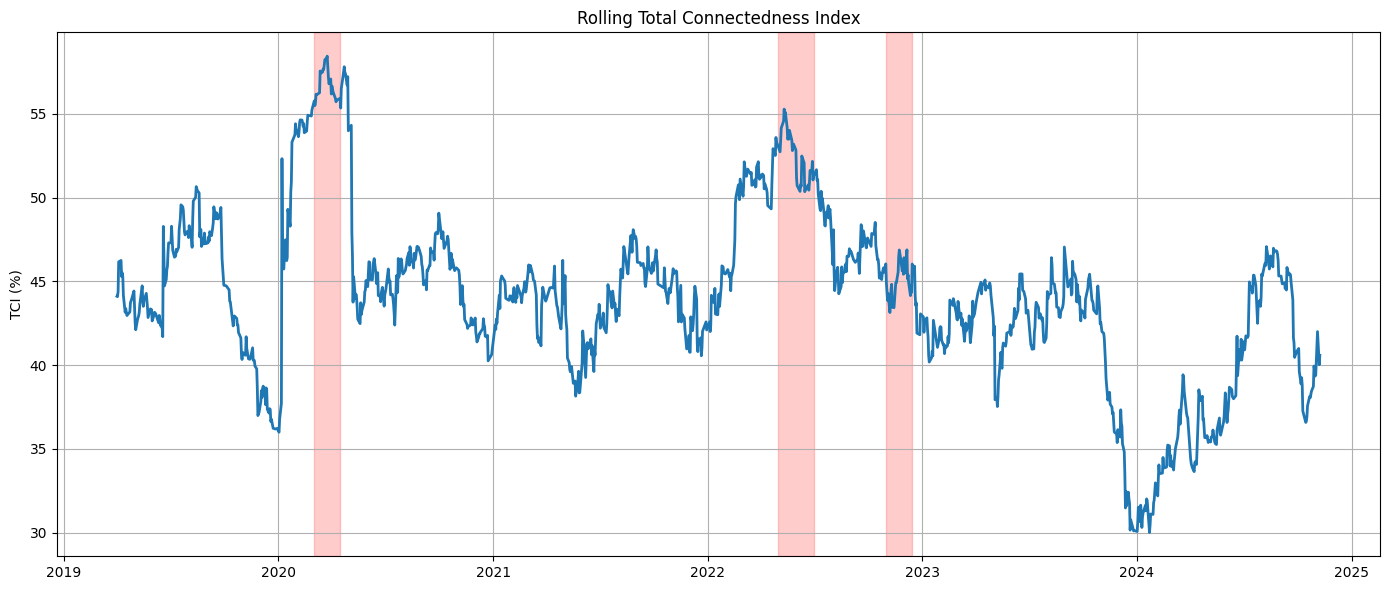

In [53]:
plot_rolling_tci()

### Diversification

In [36]:
weights = compute_dynamic_weights()
weights.head()

,date,weight_BTC-USD,weight_GC=F,weight_^GSPC,weight_ETH-USD,weight_^NSEI
0,2019-02-11,0.000000,0.963469,1.000000,0.0,1.0
1,2019-02-12,0.000000,0.982132,1.000000,0.0,1.0
2,2019-02-14,0.000000,0.979392,1.000000,0.0,1.0
3,2019-02-15,0.000000,0.981673,1.000000,0.0,1.0
4,2019-02-19,0.001444,0.977516,0.998556,0.0,1.0


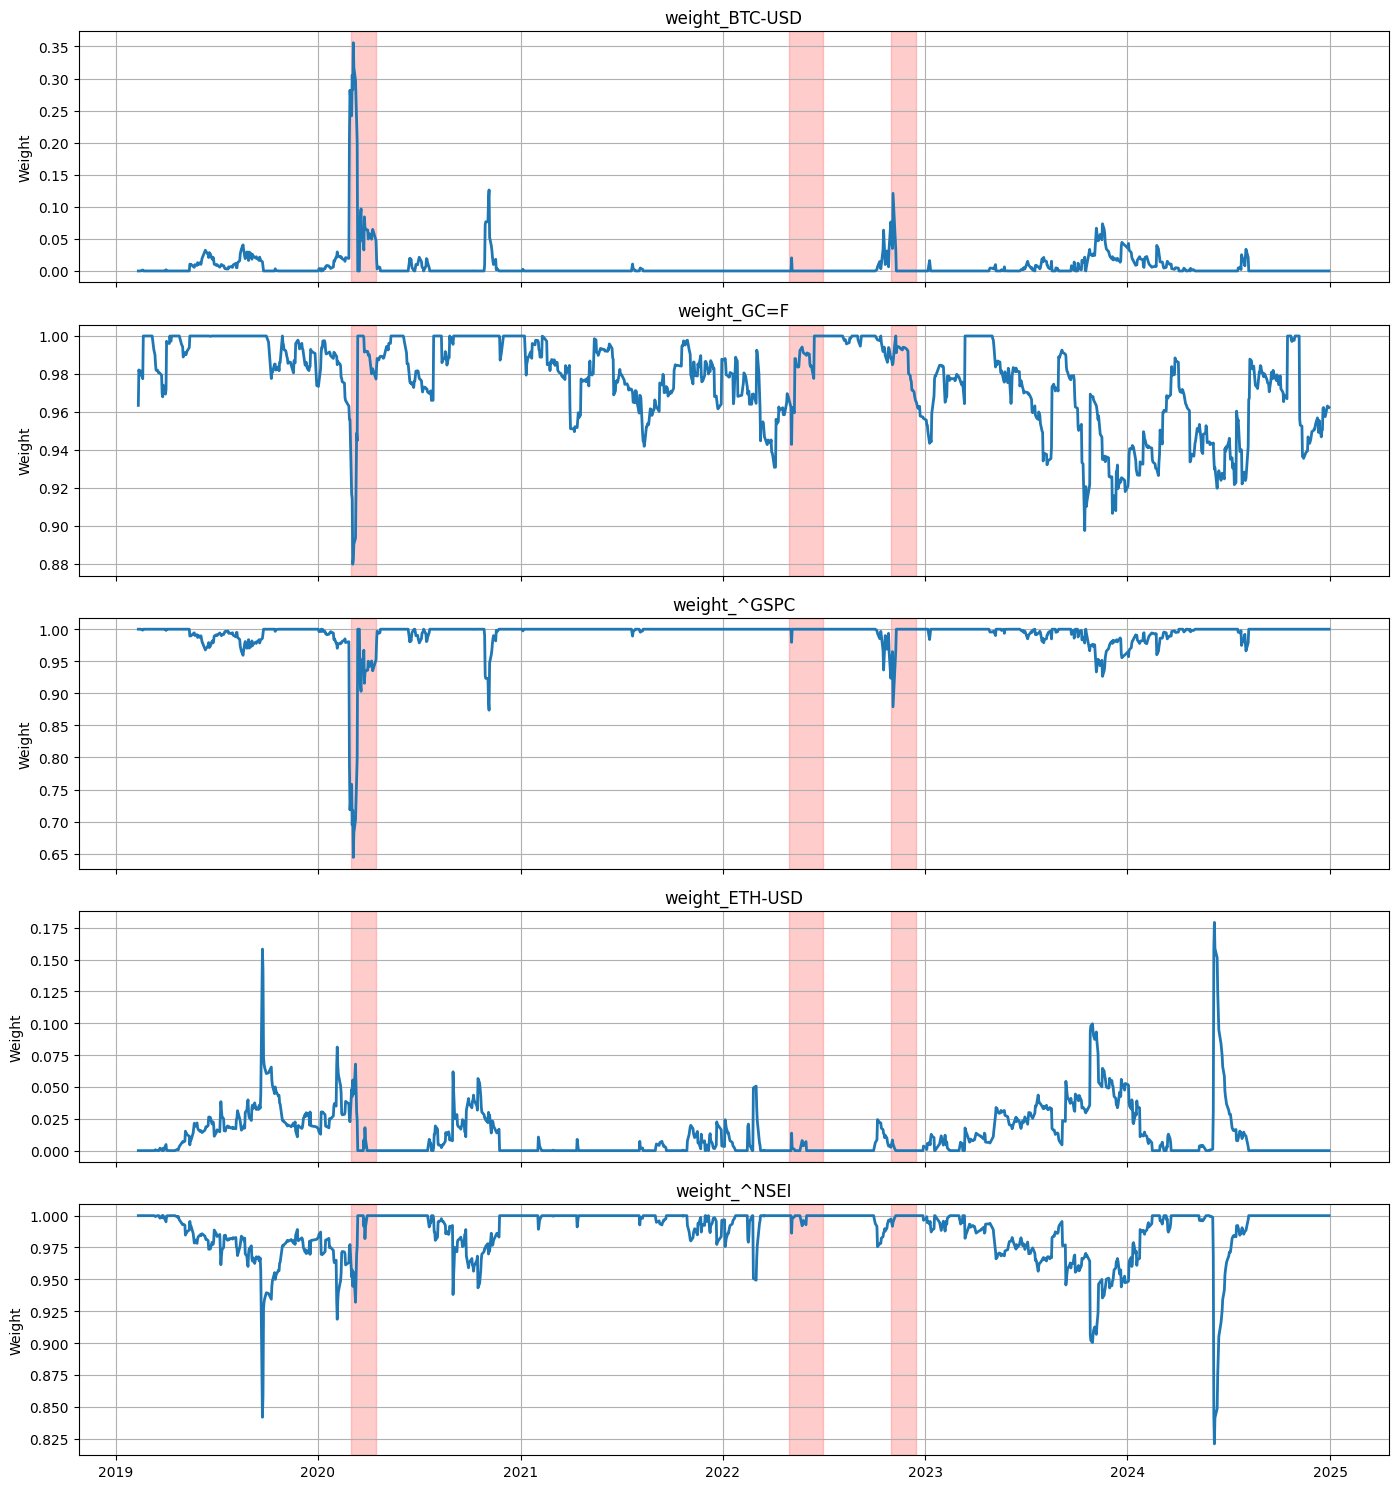

In [37]:
plot_dynamic_weights()

In [38]:
hedge = compute_hedge_ratios()
hedge.head()

,date,hedge_BTC-USD_with_GC=F,hedge_BTC-USD_with_^GSPC,hedge_ETH-USD_with_^NSEI
0,2019-02-11,0.539930,1.343376,1.220294
1,2019-02-12,0.735346,1.531347,1.431850
2,2019-02-14,0.695544,1.021436,1.486392
3,2019-02-15,0.718244,1.090585,1.557863
4,2019-02-19,0.674000,0.979392,1.510252


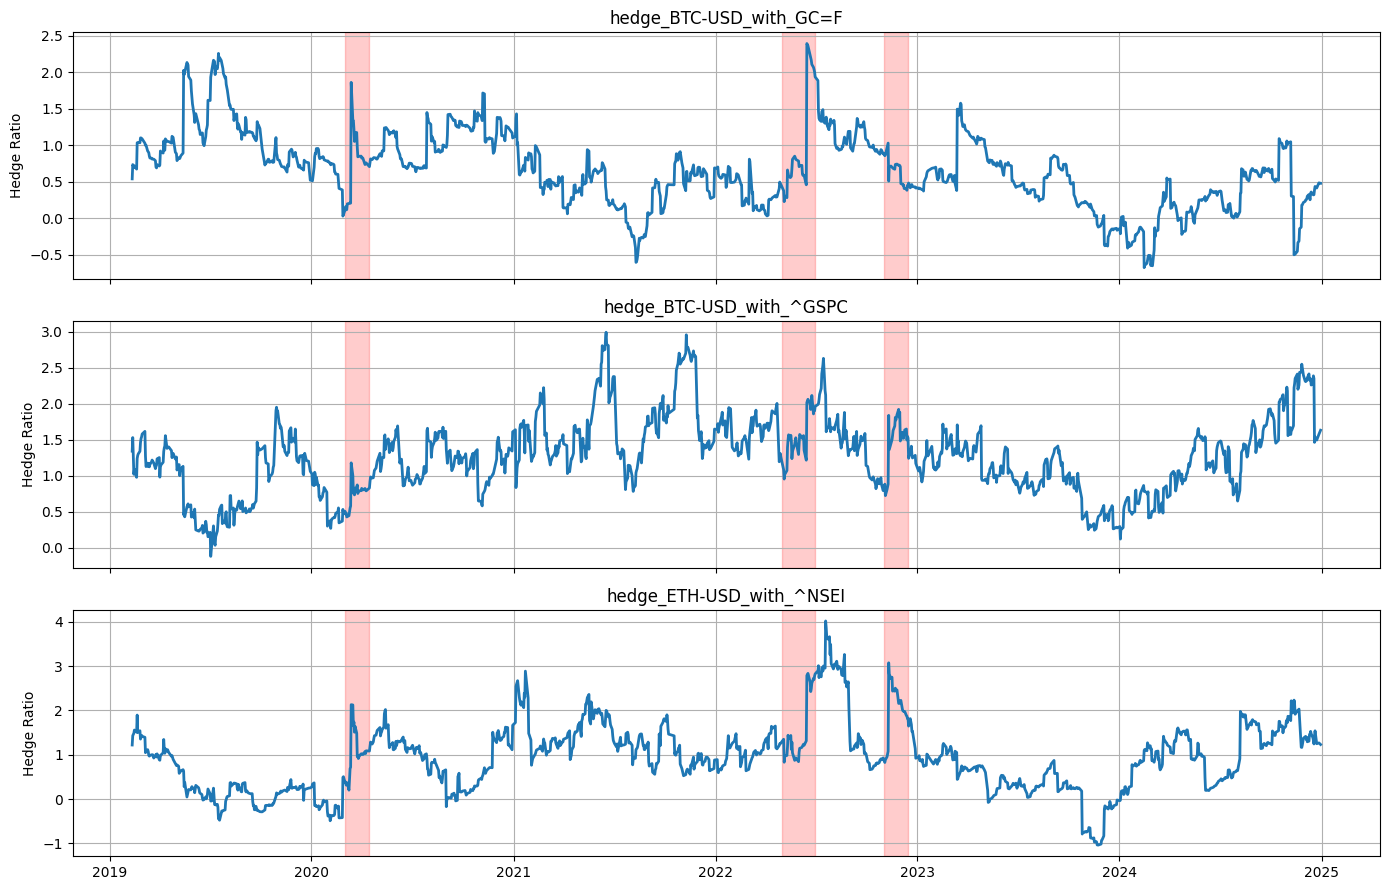

In [39]:
plot_hedge_ratios()

In [40]:
he = compute_hedging_effectiveness()
he


=== HEDGING EFFECTIVENESS ===
             pair  normal_HE_pct  crash_HE_pct
0   BTC-USD__GC=F       1.508646      1.082058
1  BTC-USD__^GSPC       6.572850     28.411072
2  ETH-USD__^NSEI       0.713980      9.418216


,pair,normal_HE_pct,crash_HE_pct
0,BTC-USD__GC=F,1.508646,1.082058
1,BTC-USD__^GSPC,6.572850,28.411072
2,ETH-USD__^NSEI,0.713980,9.418216


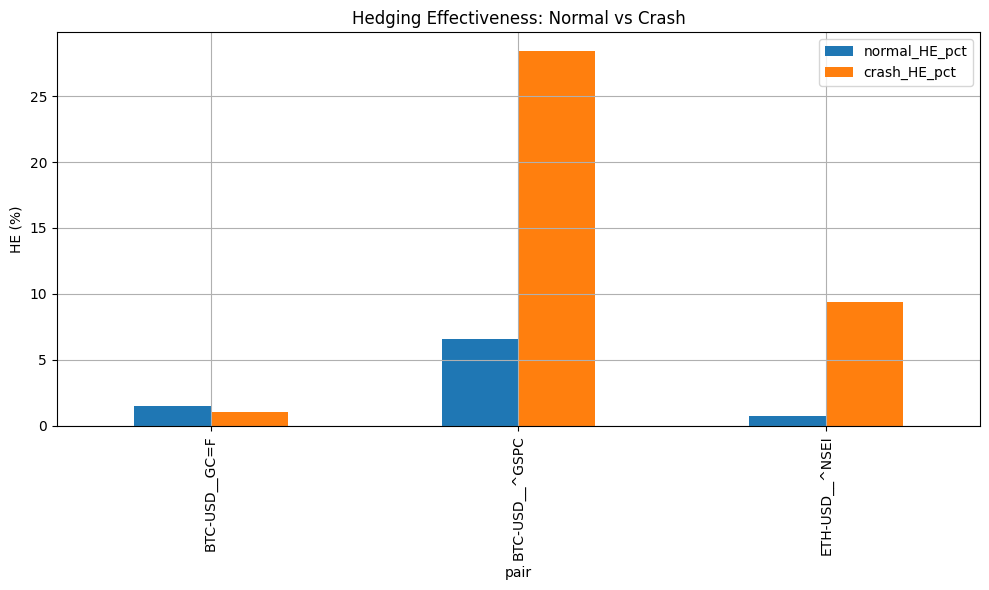

In [41]:
plot_hedging_effectiveness()

### LSTM

#### RUN 1

In [122]:
model, history, X_test, y_test = train_lstm(
    lookback=30,
    epochs=50,
    batch_size=16,
    best_model_path="model_32/"
)


=== DATASET ===
(1210, 13)

=== LABEL DISTRIBUTION ===
crash_label
0    1119
1      91
Name: count, dtype: int64

=== DATA DISTRIBUTION ===
Train crashes: 35 / 71
Validation crashes: 27 / 53
Test crashes: 29 / 56

=== UNIQUE LABELS ===
Train: [0 1]
Validation: [0 1]
Test: [0 1]
Epoch 1/50
1/5 [=====>........................] - ETA: 5s - loss: 0.6924 - accuracy: 0.4375
Epoch 1: val_loss improved from inf to 0.84074, saving model to model_32\
INFO:tensorflow:Assets written to: model_32\assets


INFO:tensorflow:Assets written to: model_32\assets


5/5 [==============================] - 4s 592ms/step - loss: 0.6273 - accuracy: 0.6620 - val_loss: 0.8407 - val_accuracy: 0.1132
Epoch 2/50
1/5 [=====>........................] - ETA: 0s - loss: 0.5881 - accuracy: 0.8750
Epoch 2: val_loss improved from 0.84074 to 0.78382, saving model to model_32\
INFO:tensorflow:Assets written to: model_32\assets


INFO:tensorflow:Assets written to: model_32\assets


5/5 [==============================] - 2s 528ms/step - loss: 0.5351 - accuracy: 0.9014 - val_loss: 0.7838 - val_accuracy: 0.2830
Epoch 3/50
1/5 [=====>........................] - ETA: 0s - loss: 0.4463 - accuracy: 0.9375
Epoch 3: val_loss improved from 0.78382 to 0.73216, saving model to model_32\
INFO:tensorflow:Assets written to: model_32\assets


...

5/5 [==============================] - 3s 826ms/step - loss: 0.1398 - accuracy: 0.9859 - val_loss: 0.5062 - val_accuracy: 0.8113
Epoch 11/50
1/5 [=====>........................] - ETA: 0s - loss: 0.1015 - accuracy: 1.0000
Epoch 11: val_loss improved from 0.50621 to 0.49643, saving model to model_32\
INFO:tensorflow:Assets written to: model_32\assets


INFO:tensorflow:Assets written to: model_32\assets


5/5 [==============================] - 4s 980ms/step - loss: 0.1239 - accuracy: 0.9859 - val_loss: 0.4964 - val_accuracy: 0.8113
Epoch 12/50
1/5 [=====>........................] - ETA: 0s - loss: 0.0996 - accuracy: 1.0000
Epoch 12: val_loss improved from 0.49643 to 0.49530, saving model to model_32\
INFO:tensorflow:Assets written to: model_32\assets


INFO:tensorflow:Assets written to: model_32\assets


5/5 [==============================] - 3s 720ms/step - loss: 0.1104 - accuracy: 0.9859 - val_loss: 0.4953 - val_accuracy: 0.8113
Epoch 13/50
1/5 [=====>........................] - ETA: 0s - loss: 0.0937 - accuracy: 1.0000
Epoch 13: val_loss did not improve from 0.49530
5/5 [==============================] - 0s 15ms/step - loss: 0.0955 - accuracy: 0.9859 - val_loss: 0.5001 - val_accuracy: 0.8113
Epoch 14/50
1/5 [=====>........................] - ETA: 0s - loss: 0.1049 - accuracy: 0.9375
Epoch 14: val_loss did not improve from 0.49530
5/5 [==============================] - 0s 14ms/step - loss: 0.0869 - accuracy: 0.9859 - val_loss: 0.5074 - val_accuracy: 0.8113
Epoch 15/50
1/5 [=====>........................] - ETA: 0s - loss: 0.0915 - accuracy: 0.9375
Epoch 15: val_loss did not improve from 0.49530
5/5 [==============================] - 0s 14ms/step - loss: 0.0742 - accuracy: 0.9859 - val_loss: 0.5169 - val_accuracy: 0.8113
Epoch 16/50
1/5 [=====>........................] - ETA: 0s - los

In [123]:
metrics_df, cm, y_prob, y_pred = evaluate_lstm(
    model,
    X_test,
    y_test,
    threshold=0.5
)

metrics_df

2/2 [==============================] - 1s 7ms/step

=== LSTM EVALUATION ===
    auc_roc  precision    recall  f1_score
0  0.924649        1.0  0.517241  0.681818

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

      Normal       0.66      1.00      0.79        27
       Crash       1.00      0.52      0.68        29

    accuracy                           0.75        56
   macro avg       0.83      0.76      0.74        56
weighted avg       0.84      0.75      0.74        56



,auc_roc,precision,recall,f1_score
0,0.924649,1.0,0.517241,0.681818


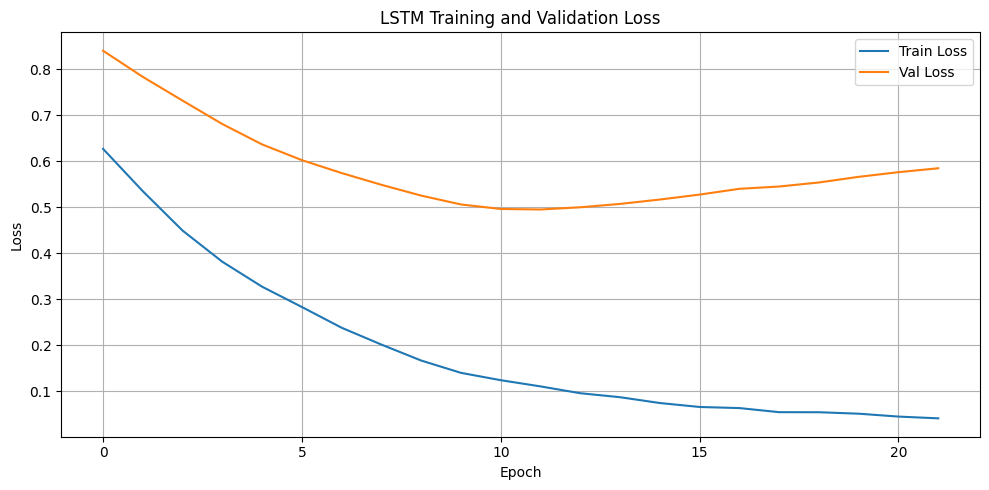

In [124]:
plot_training_history(history)

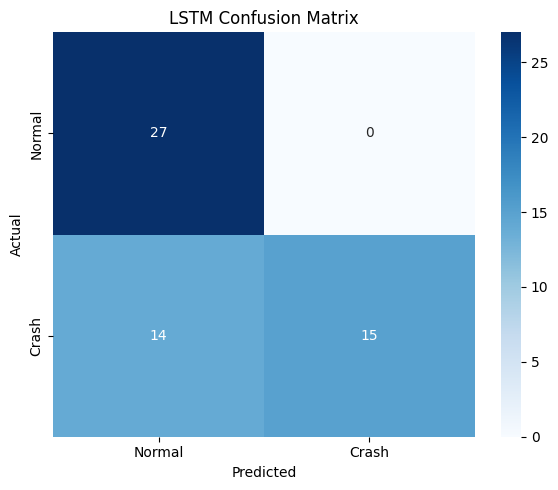

In [125]:
plot_confusion_matrix(cm)

#### RUN 2 

In [ ]:
model, history, X_test, y_test = train_lstm(
    lookback=30,
    epochs=50,
    batch_size=16,
    best_model_path="model_16/"
)


=== DATASET ===
(1210, 13)

=== LABEL DISTRIBUTION ===
crash_label
0    1119
1      91
Name: count, dtype: int64

=== DATA DISTRIBUTION ===
Train crashes: 35 / 71
Validation crashes: 27 / 53
Test crashes: 29 / 56

=== UNIQUE LABELS ===
Train: [0 1]
Validation: [0 1]
Test: [0 1]
Epoch 1/50
1/5 [=====>........................] - ETA: 5s - loss: 0.7822 - accuracy: 0.3125
Epoch 1: val_loss improved from inf to 0.67756, saving model to model_16\
INFO:tensorflow:Assets written to: model_16\assets


INFO:tensorflow:Assets written to: model_16\assets


5/5 [==============================] - 4s 582ms/step - loss: 0.7820 - accuracy: 0.2817 - val_loss: 0.6776 - val_accuracy: 0.5094
Epoch 2/50
1/5 [=====>........................] - ETA: 0s - loss: 0.7187 - accuracy: 0.2500
Epoch 2: val_loss improved from 0.67756 to 0.66094, saving model to model_16\
INFO:tensorflow:Assets written to: model_16\assets


INFO:tensorflow:Assets written to: model_16\assets


5/5 [==============================] - 3s 676ms/step - loss: 0.7421 - accuracy: 0.2535 - val_loss: 0.6609 - val_accuracy: 0.5094
Epoch 3/50
1/5 [=====>........................] - ETA: 0s - loss: 0.6980 - accuracy: 0.4375
Epoch 3: val_loss improved from 0.66094 to 0.64677, saving model to model_16\
INFO:tensorflow:Assets written to: model_16\assets


...

5/5 [==============================] - 4s 951ms/step - loss: 0.0490 - accuracy: 1.0000 - val_loss: 0.4321 - val_accuracy: 0.7358
Epoch 49/50
1/5 [=====>........................] - ETA: 0s - loss: 0.0549 - accuracy: 1.0000
Epoch 49: val_loss improved from 0.43215 to 0.43198, saving model to model_16\
INFO:tensorflow:Assets written to: model_16\assets


INFO:tensorflow:Assets written to: model_16\assets


5/5 [==============================] - 5s 1s/step - loss: 0.0412 - accuracy: 1.0000 - val_loss: 0.4320 - val_accuracy: 0.7358
Epoch 50/50
1/5 [=====>........................] - ETA: 0s - loss: 0.0603 - accuracy: 1.0000
Epoch 50: val_loss improved from 0.43198 to 0.43150, saving model to model_16\
INFO:tensorflow:Assets written to: model_16\assets


INFO:tensorflow:Assets written to: model_16\assets


5/5 [==============================] - 4s 877ms/step - loss: 0.0520 - accuracy: 1.0000 - val_loss: 0.4315 - val_accuracy: 0.7547


In [108]:
metrics_df, cm, y_prob, y_pred = evaluate_lstm(
    model,
    X_test,
    y_test,
    threshold=0.5
)

metrics_df

2/2 [==============================] - 1s 7ms/step

=== LSTM EVALUATION ===
   auc_roc  precision    recall  f1_score
0  0.94636        1.0  0.413793  0.585366

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

      Normal       0.61      1.00      0.76        27
       Crash       1.00      0.41      0.59        29

    accuracy                           0.70        56
   macro avg       0.81      0.71      0.67        56
weighted avg       0.81      0.70      0.67        56



,auc_roc,precision,recall,f1_score
0,0.94636,1.0,0.413793,0.585366


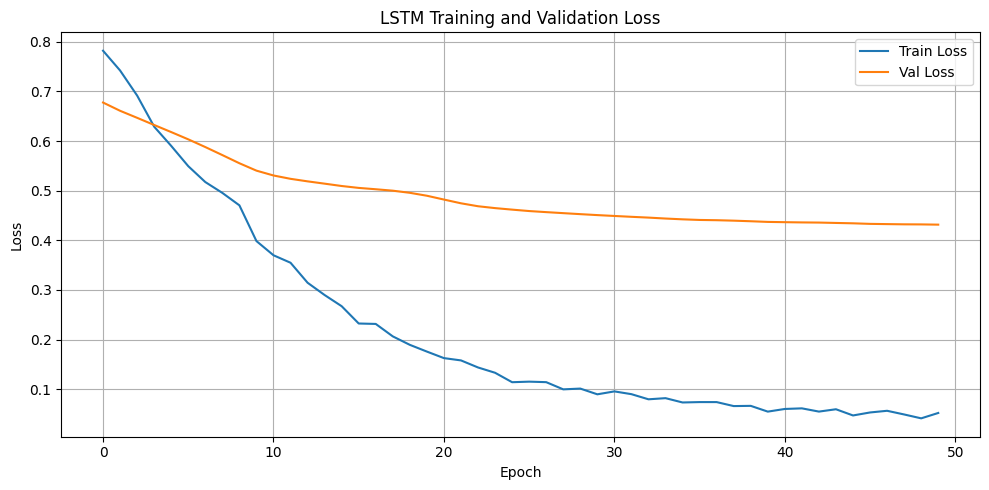

In [109]:
plot_training_history(history)

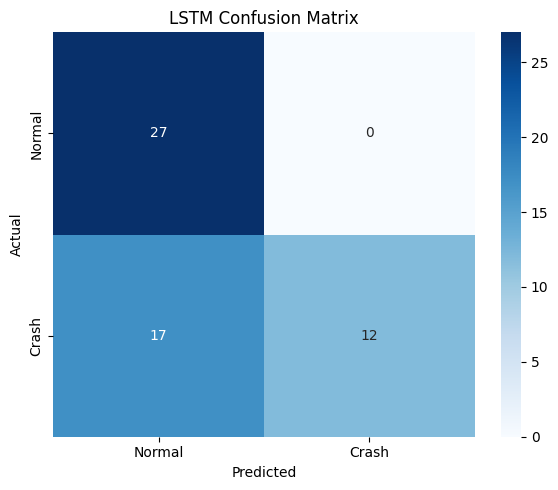

In [110]:
plot_confusion_matrix(cm)

#### RUN 3

In [112]:
model, history, X_test, y_test = train_lstm(
    lookback=30,
    epochs=50,
    batch_size=16,
    best_model_path="model_8/"
)


=== DATASET ===
(1210, 13)

=== LABEL DISTRIBUTION ===
crash_label
0    1119
1      91
Name: count, dtype: int64

=== DATA DISTRIBUTION ===
Train crashes: 35 / 71
Validation crashes: 27 / 53
Test crashes: 29 / 56

=== UNIQUE LABELS ===
Train: [0 1]
Validation: [0 1]
Test: [0 1]
Epoch 1/50
1/5 [=====>........................] - ETA: 5s - loss: 0.7154 - accuracy: 0.3750
Epoch 1: val_loss improved from inf to 0.65192, saving model to model_8\
INFO:tensorflow:Assets written to: model_8\assets


INFO:tensorflow:Assets written to: model_8\assets


5/5 [==============================] - 4s 614ms/step - loss: 0.6629 - accuracy: 0.6338 - val_loss: 0.6519 - val_accuracy: 0.5283
Epoch 2/50
1/5 [=====>........................] - ETA: 0s - loss: 0.6400 - accuracy: 0.6875
Epoch 2: val_loss improved from 0.65192 to 0.65084, saving model to model_8\
INFO:tensorflow:Assets written to: model_8\assets


INFO:tensorflow:Assets written to: model_8\assets


5/5 [==============================] - 3s 764ms/step - loss: 0.6456 - accuracy: 0.6761 - val_loss: 0.6508 - val_accuracy: 0.5472
Epoch 3/50
1/5 [=====>........................] - ETA: 0s - loss: 0.5782 - accuracy: 0.8125
Epoch 3: val_loss improved from 0.65084 to 0.64995, saving model to model_8\
INFO:tensorflow:Assets written to: model_8\assets


...

5/5 [==============================] - 2s 525ms/step - loss: 0.2931 - accuracy: 0.9577 - val_loss: 0.5929 - val_accuracy: 0.7547
Epoch 23/50
1/5 [=====>........................] - ETA: 0s - loss: 0.3183 - accuracy: 0.9375
Epoch 23: val_loss improved from 0.59288 to 0.59163, saving model to model_8\
INFO:tensorflow:Assets written to: model_8\assets


INFO:tensorflow:Assets written to: model_8\assets


5/5 [==============================] - 2s 568ms/step - loss: 0.2723 - accuracy: 0.9718 - val_loss: 0.5916 - val_accuracy: 0.7547
Epoch 24/50
1/5 [=====>........................] - ETA: 0s - loss: 0.2857 - accuracy: 1.0000
Epoch 24: val_loss improved from 0.59163 to 0.59115, saving model to model_8\
INFO:tensorflow:Assets written to: model_8\assets


INFO:tensorflow:Assets written to: model_8\assets


5/5 [==============================] - 2s 524ms/step - loss: 0.2645 - accuracy: 0.9718 - val_loss: 0.5911 - val_accuracy: 0.7547
Epoch 25/50
1/5 [=====>........................] - ETA: 0s - loss: 0.2223 - accuracy: 1.0000
Epoch 25: val_loss did not improve from 0.59115
5/5 [==============================] - 0s 15ms/step - loss: 0.2496 - accuracy: 0.9718 - val_loss: 0.5914 - val_accuracy: 0.7736
Epoch 26/50
1/5 [=====>........................] - ETA: 0s - loss: 0.2308 - accuracy: 1.0000
Epoch 26: val_loss did not improve from 0.59115
5/5 [==============================] - 0s 15ms/step - loss: 0.2353 - accuracy: 0.9718 - val_loss: 0.5916 - val_accuracy: 0.7736
Epoch 27/50
1/5 [=====>........................] - ETA: 0s - loss: 0.2698 - accuracy: 0.9375
Epoch 27: val_loss did not improve from 0.59115
5/5 [==============================] - 0s 15ms/step - loss: 0.2323 - accuracy: 0.9718 - val_loss: 0.5916 - val_accuracy: 0.7925
Epoch 28/50
1/5 [=====>........................] - ETA: 0s - los

In [113]:
metrics_df, cm, y_prob, y_pred = evaluate_lstm(
    model,
    X_test,
    y_test,
    threshold=0.5
)

metrics_df

2/2 [==============================] - 0s 5ms/step

=== LSTM EVALUATION ===
    auc_roc  precision  recall  f1_score
0  0.681992        0.0     0.0       0.0

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

      Normal       0.48      1.00      0.65        27
       Crash       0.00      0.00      0.00        29

    accuracy                           0.48        56
   macro avg       0.24      0.50      0.33        56
weighted avg       0.23      0.48      0.31        56



,auc_roc,precision,recall,f1_score
0,0.681992,0.0,0.0,0.0


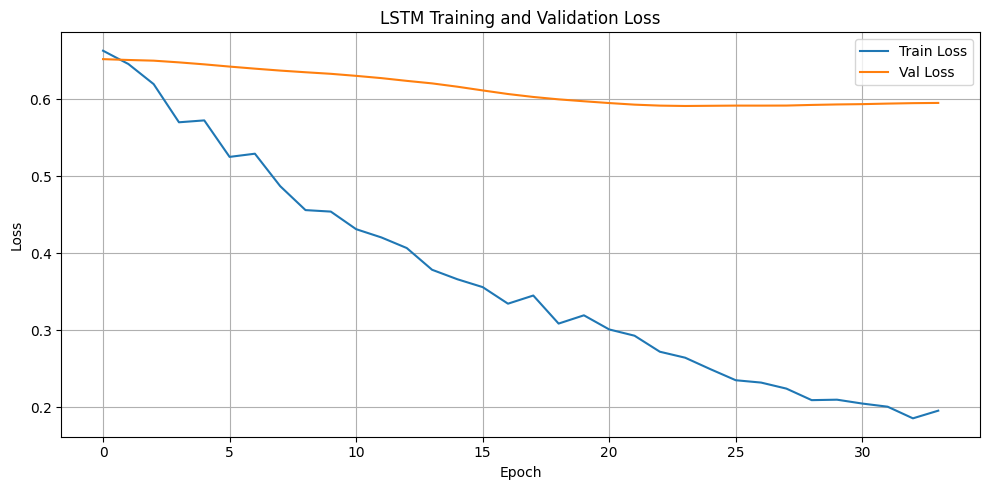

In [114]:
plot_training_history(history)

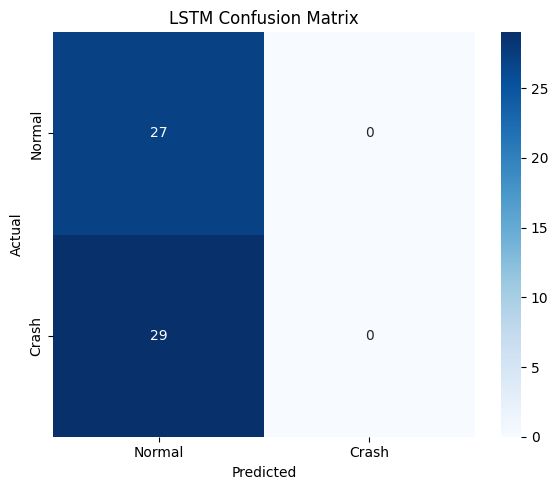

In [115]:
plot_confusion_matrix(cm)